# Intersection scenario Analysis (MetaDrive)

This notebook reads **`Intersection_analysis_compilation.xlsx`** and builds charts for my report:

1. **Overview dashboard** — success rate, average crashes, average finish time, plus a number table.
2. **Detailed comparison** — 
success vs fail **as % of each policy’s runs**, **timeout %** (stuck), 
**% of runs with crashes** (aggressive = worse), and 
**trip time in seconds** among successful timed runs (time cannot be a %; axis is seconds).

**Policies:** IDM, Expert, IDM trajectory.

**Requirements:** `pandas`, `matplotlib`, `openpyxl`.

**Conclusions** for Intersection scenario


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Workbook in the same folder as this notebook (set Jupyter cwd to this folder, or edit path below)
NOTEBOOK_DIR = Path.cwd()
EXCEL_PATH = NOTEBOOK_DIR / "Intersection_analysis_compilation.xlsx"

POLICY_SHEETS = {
    "IDM": "intersection_idm",
    "Expert": "intersection_expert",
    "IDM trajectory": "intersection_idmtrajectory",
}
POLICY_COLORS = {"IDM": "#3498db", "Expert": "#9b59b6", "IDM trajectory": "#f39c12"}

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        plt.style.use("ggplot")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

C:\Users\User\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\User\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Jupyter: notebook dir is cwd when you "Run All"
if not EXCEL_PATH.is_file():
    EXCEL_PATH = Path.cwd() / "Intersection_analysis_compilation.xlsx"

def load_policy_sheet(path: Path, policy_label: str, sheet_name: str) -> pd.DataFrame:
    """Row 0 is a title row; row 1 holds column headers."""
    df = pd.read_excel(path, sheet_name=sheet_name, header=1)
    df["policy"] = policy_label
    return df


def normalize_episode_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.dropna(subset=["Pass"], how="all")
    out["pass_bool"] = out["Pass"].astype(str).str.strip().str.upper().eq("YES")
    out["timeout_bool"] = out["Timeout"].astype(str).str.strip().str.upper().eq("YES")
    out["crash_count"] = pd.to_numeric(out["Crash Count"], errors="coerce")
    tcol = "Time Taken to Reach Goal (sim s)"
    out["time_to_goal_s"] = pd.to_numeric(out[tcol], errors="coerce")
    out["avg_speed_kmh"] = pd.to_numeric(out["Average Speed (km/h)"], errors="coerce")
    return out


if not EXCEL_PATH.is_file():
    raise FileNotFoundError(f"Workbook not found: {EXCEL_PATH.resolve()}")

frames = [
    normalize_episode_frame(load_policy_sheet(EXCEL_PATH, label, sheet))
    for label, sheet in POLICY_SHEETS.items()
]
all_episodes = pd.concat(frames, ignore_index=True)

summary = (
    all_episodes.groupby("policy", sort=False)
    .agg(
        episodes=("pass_bool", "count"),
        pass_rate=("pass_bool", "mean"),
        timeout_rate=("timeout_bool", "mean"),
        mean_crashes=("crash_count", "mean"),
        median_crashes=("crash_count", "median"),
        mean_time_success_s=("time_to_goal_s", lambda s: s.dropna().mean()),
        median_time_success_s=("time_to_goal_s", lambda s: s.dropna().median()),
        std_time_success_s=("time_to_goal_s", lambda s: s.dropna().std()),
        n_with_finish_time=("time_to_goal_s", lambda s: int(s.notna().sum())),
        pct_runs_with_crash=(
            "crash_count",
            lambda s: float((s.fillna(0) > 0).mean() * 100),
        ),
    )
    .reset_index()
)
summary["pass_pct"] = summary["pass_rate"] * 100
summary["fail_pct"] = (1 - summary["pass_rate"]) * 100
summary["timeout_pct"] = summary["timeout_rate"] * 100
summary["pct_runs_with_finish_time"] = (
    summary["n_with_finish_time"] / summary["episodes"] * 100
)

summary.round(3)

,policy,episodes,pass_rate,timeout_rate,mean_crashes,median_crashes,mean_time_success_s,median_time_success_s,std_time_success_s,n_with_finish_time,pct_runs_with_crash,pass_pct,fail_pct,timeout_pct,pct_runs_with_finish_time
0,IDM,50,1.000,0.000,2.820,2.0,50.598,50.6,4.539,50,66.000,100.000,0.000,0.000,100.000
1,Expert,39,0.667,0.231,1.282,0.0,59.754,57.5,10.031,28,48.718,66.667,33.333,23.077,71.795
2,IDM trajectory,40,0.900,0.000,5.100,1.0,53.872,52.8,9.765,36,62.500,90.000,10.000,0.000,90.000


## Main result for my analysis overview 

The **first figure** below has **three bar charts** (same three policies) and a **summary table**.

1. **Success rate** — % of runs that **reached the goal** (`Pass = YES`).
2. **% runs with at least one crash** — higher = more aggressive / worse (fair across different test lengths).
3. **Average finish time** — only runs with a **numeric** finish time (seconds). Small label shows **what % of runs** had a time.

The table repeats the same numbers for Word/PPT. **Run the next section** for success/fail **counts**, **timeouts (stuck)**, **most aggressive policy** (highest mean crashes), and **trip-time** box plots.


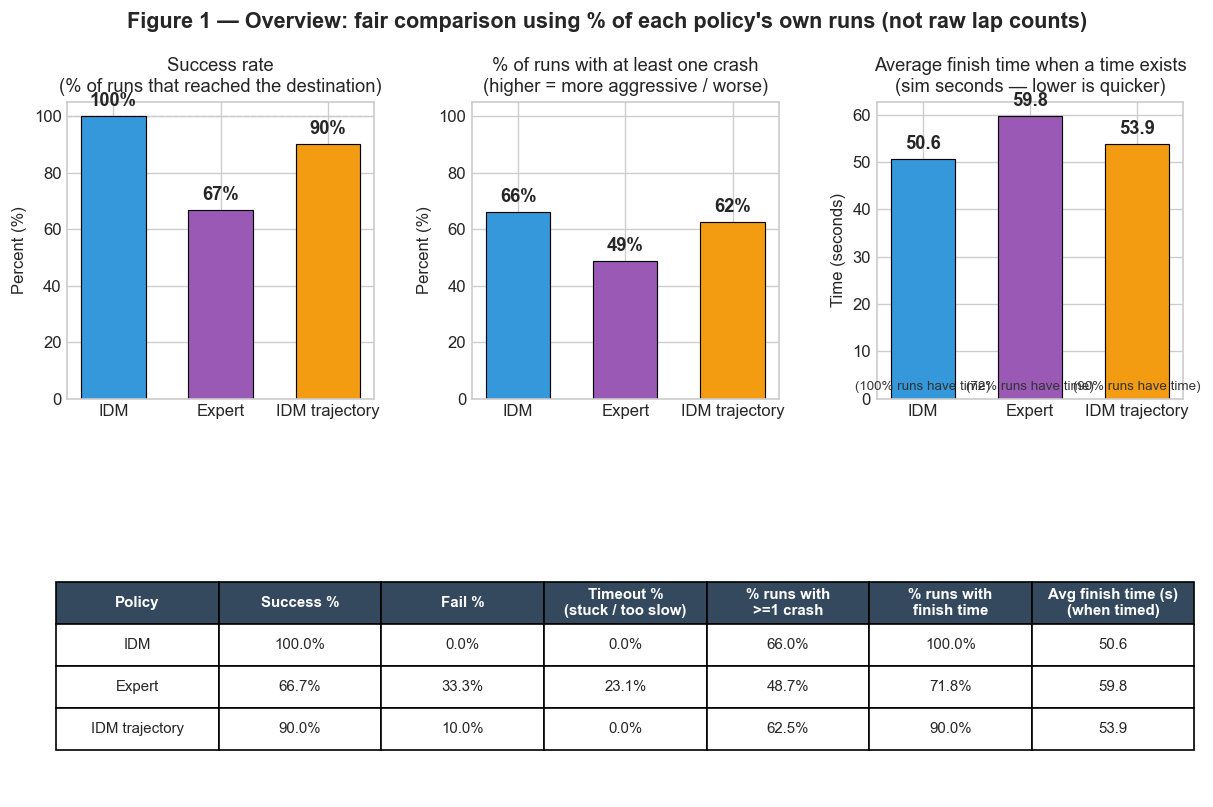

Raw run counts (not used in charts): 
  IDM: total=50, timed=50
  Expert: total=39, timed=28
  IDM trajectory: total=40, timed=36
————————————————————————————————————————————————————————————
Quick read (by %):
  • Highest success %: IDM
  • Lowest % runs with crashes: Expert
  • Lowest timeout %: IDM
  • Shortest avg finish time (among timed runs): IDM
————————————————————————————————————————————————————————————


In [3]:
policies = summary["policy"].tolist()
colors = [POLICY_COLORS[p] for p in policies]

fig = plt.figure(figsize=(12, 7.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1.15, 1.0], hspace=0.5, wspace=0.32)

# --- All policy-vs-policy charts use RATES (%) of THAT policy's runs — not raw lap totals ---
titles = [
    "Success rate\n(% of runs that reached the destination)",
    "% of runs with at least one crash\n(higher = more aggressive / worse)",
    "Average finish time when a time exists\n(sim seconds — lower is quicker)",
]
series = [
    summary["pass_pct"].to_numpy(),
    summary["pct_runs_with_crash"].to_numpy(),
    summary["mean_time_success_s"].to_numpy(),
]
y_labels = ["Percent (%)", "Percent (%)", "Time (seconds)"]

for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    x = np.arange(len(policies))
    bars = ax.bar(x, series[i], color=colors, edgecolor="black", linewidth=0.7, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(policies, fontsize=10)
    ax.set_ylabel(y_labels[i], fontsize=10)
    ax.set_title(titles[i], fontsize=11)
    if i in (0, 1):
        ax.set_ylim(0, 105)
        if i == 0:
            ax.axhline(100, color="#bbb", linestyle="--", linewidth=0.8, zorder=0)
    top = ax.get_ylim()[1]
    for j, b in enumerate(bars):
        h = float(series[i][j])
        if not np.isfinite(h):
            continue
        if i in (0, 1):
            lab = f"{h:.0f}%"
        else:
            lab = f"{h:.1f}"
        ax.text(
            b.get_x() + b.get_width() / 2,
            min(h + 0.02 * top, top * 0.98),
            lab,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )
    if i == 2:
        pct_t = summary["pct_runs_with_finish_time"].to_numpy()
        for j, b in enumerate(bars):
            ax.text(
                b.get_x() + b.get_width() / 2,
                0.02 * top,
                f"({pct_t[j]:.0f}% runs have time)",
                ha="center",
                va="bottom",
                fontsize=8,
                color="#333",
            )

# --- Summary table: percentages (fair comparison across different test sizes) ---
ax_tbl = fig.add_subplot(gs[1, :])
ax_tbl.axis("off")

rows = []
for _, row in summary.iterrows():
    rows.append(
        [
            row["policy"],
            f"{row['pass_pct']:.1f}%",
            f"{row['fail_pct']:.1f}%",
            f"{row['timeout_pct']:.1f}%",
            f"{row['pct_runs_with_crash']:.1f}%",
            f"{row['pct_runs_with_finish_time']:.1f}%",
            f"{row['mean_time_success_s']:.1f}" if pd.notna(row["mean_time_success_s"]) else "—",
        ]
    )

tbl = ax_tbl.table(
    cellText=rows,
    colLabels=[
        "Policy",
        "Success %",
        "Fail %",
        "Timeout %\n(stuck / too slow)",
        "% runs with\n>=1 crash",
        "% runs with\nfinish time",
        "Avg finish time (s)\n(when timed)",
    ],
    loc="center",
    cellLoc="center",
    colLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.02, 2.1)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#34495e")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")

fig.suptitle(
    "Figure 1 — Overview: fair comparison using % of each policy's own runs (not raw lap counts)",
    fontsize=13,
    fontweight="bold",
    y=0.98,
)

plt.show()

# Raw counts (for your appendix / reproducibility only)
print("Raw run counts (not used in charts): ")
for _, row in summary.iterrows():
    print(
        f"  {row['policy']}: total={int(row['episodes'])}, "
        f"timed={int(row['n_with_finish_time'])}"
    )

best_ok = summary.loc[summary["pass_pct"].idxmax(), "policy"]
safest = summary.loc[summary["pct_runs_with_crash"].idxmin(), "policy"]
st = summary.dropna(subset=["mean_time_success_s"])
fastest = st.loc[st["mean_time_success_s"].idxmin(), "policy"] if len(st) else "—"
lowest_timeout = summary.loc[summary["timeout_pct"].idxmin(), "policy"]
print("—" * 60)
print("Quick read (by %):")
print(f"  • Highest success %: {best_ok}")
print(f"  • Lowest % runs with crashes: {safest}")
print(f"  • Lowest timeout %: {lowest_timeout}")
print(f"  • Shortest avg finish time (among timed runs): {fastest}")
print("—" * 60)


## More detail for success / fail, stuck (timeout), aggression (crashes), trip time

Read each subplot in plain terms:

- **Success vs fail:** **percent** of runs that reached the destination vs failed (each bar stacks to 100% for that policy).
- **Timeouts:** **percent** of runs with `Timeout = YES` (stuck / too slow).
- **Crashes:** **percent of runs** with at least one crash (higher = more aggressive / worse).
- **Time to destination:** box plot in **seconds** (not a %) — only runs that **succeeded** and have a **numeric** finish time.


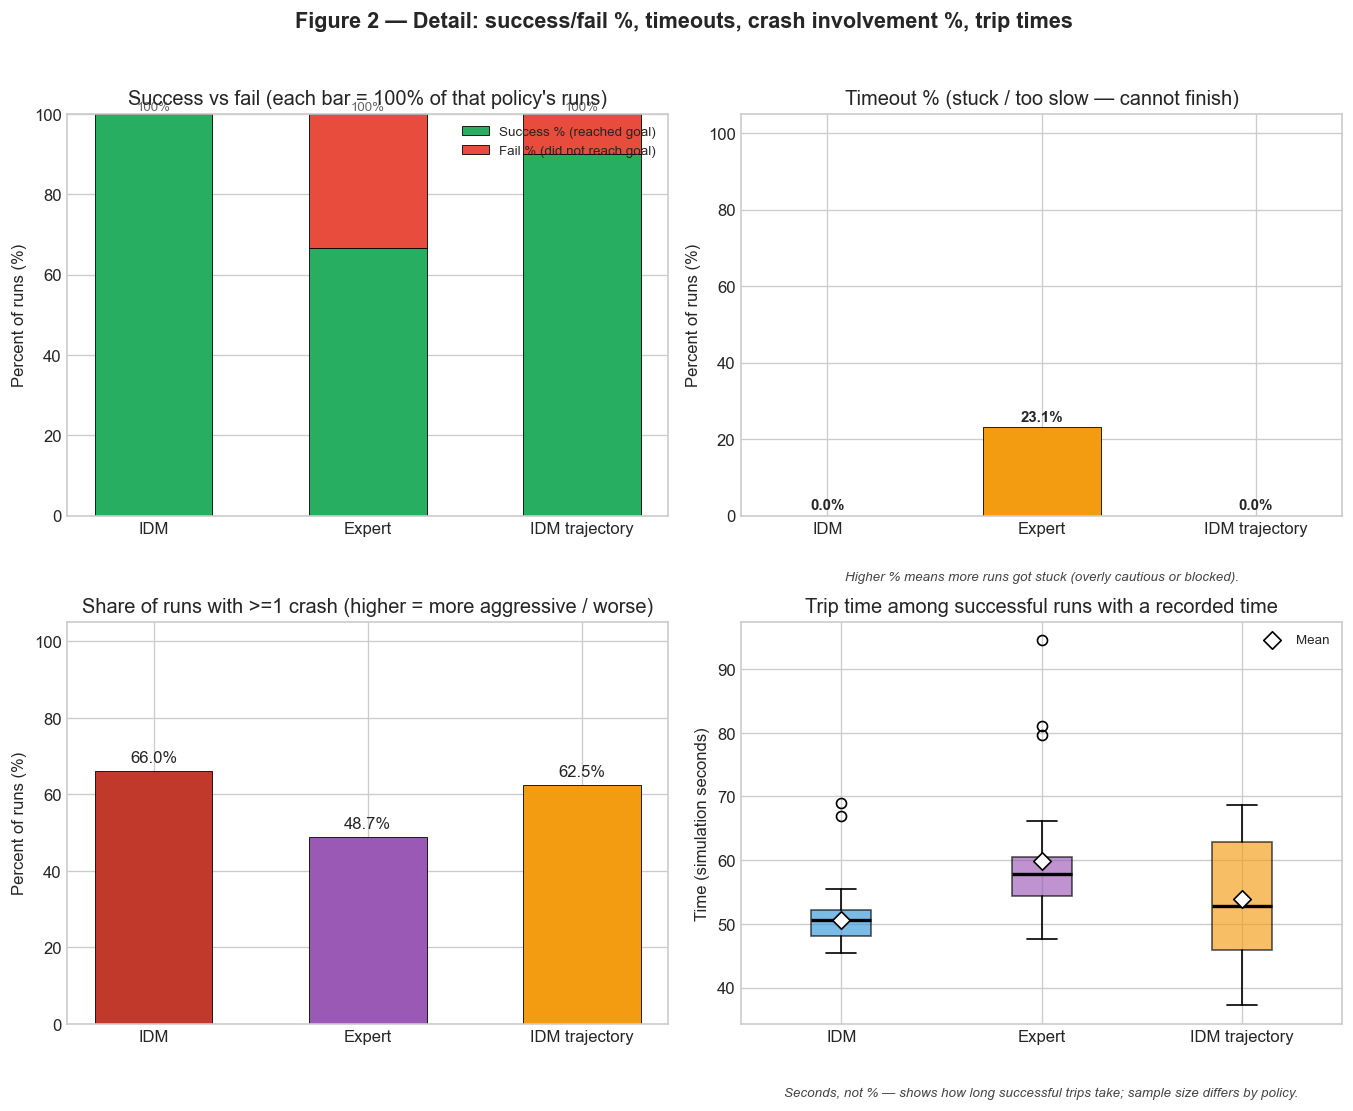

————————————————————————————————————————————————————————————
Per policy — all rates are % of THAT policy's runs:
  IDM               success 100.0%  fail   0.0%  timeout   0.0%  any-crash  66.0%
  Expert            success  66.7%  fail  33.3%  timeout  23.1%  any-crash  48.7%
  IDM trajectory    success  90.0%  fail  10.0%  timeout   0.0%  any-crash  62.5%
————————————————————————————————————————————————————————————


In [4]:
policies_order = list(POLICY_SHEETS.keys())
x = np.arange(len(policies_order))
width = 0.55

pct_success = []
pct_fail = []
pct_timeout = []
pct_any_crash = []
for pol in policies_order:
    sub = all_episodes[all_episodes["policy"] == pol]
    n = len(sub)
    if n == 0:
        pct_success.append(0.0)
        pct_fail.append(0.0)
        pct_timeout.append(0.0)
        pct_any_crash.append(0.0)
        continue
    pct_success.append(100.0 * sub["pass_bool"].mean())
    pct_fail.append(100.0 * (~sub["pass_bool"]).mean())
    pct_timeout.append(100.0 * sub["timeout_bool"].mean())
    pct_any_crash.append(100.0 * (sub["crash_count"].fillna(0) > 0).mean())

fig, axes = plt.subplots(2, 2, figsize=(11.5, 9))
fig.suptitle(
    "Figure 2 — Detail: success/fail %, timeouts, crash involvement %, trip times",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)

# --- (0,0) 100% stacked: success % + fail % ---
ax = axes[0, 0]
p_ok = np.array(pct_success)
p_bad = np.array(pct_fail)
b1 = ax.bar(
    x,
    p_ok,
    width,
    label="Success % (reached goal)",
    color="#27ae60",
    edgecolor="black",
    linewidth=0.5,
)
b2 = ax.bar(
    x,
    p_bad,
    width,
    bottom=p_ok,
    label="Fail % (did not reach goal)",
    color="#e74c3c",
    edgecolor="black",
    linewidth=0.5,
)
ax.set_xticks(x)
ax.set_xticklabels(policies_order)
ax.set_ylabel("Percent of runs (%)")
ax.set_ylim(0, 100)
ax.set_title("Success vs fail (each bar = 100% of that policy's runs)")
ax.legend(loc="upper right", fontsize=8)
for i in x:
    ax.text(i, 101, "100%", ha="center", fontsize=8, color="#666")

# --- (0,1) Timeout rate % ---
ax = axes[0, 1]
bars = ax.bar(x, pct_timeout, width, color="#f39c12", edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(policies_order)
ax.set_ylabel("Percent of runs (%)")
ax.set_ylim(0, max(105, max(pct_timeout) * 1.15 if pct_timeout else 105))
ax.set_title("Timeout % (stuck / too slow — cannot finish)")
for i, b in enumerate(bars):
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width() / 2,
        h + 0.8,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=9,
    )
ax.text(
    0.5,
    -0.16,
    "Higher % means more runs got stuck (overly cautious or blocked).",
    transform=ax.transAxes,
    ha="center",
    fontsize=8,
    style="italic",
    color="#444",
)

# --- (1,0) % runs with any crash (aggressive = worse) ---
ax = axes[1, 0]
worst_i = int(np.argmax(pct_any_crash))
bar_cols = ["#c0392b" if i == worst_i else POLICY_COLORS[pol] for i, pol in enumerate(policies_order)]
bars = ax.bar(x, pct_any_crash, width, color=bar_cols, edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(policies_order)
ax.set_ylabel("Percent of runs (%)")
ax.set_ylim(0, 105)
ax.set_title("Share of runs with >=1 crash (higher = more aggressive / worse)")
for i, b in enumerate(bars):
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width() / 2,
        h + 1.5,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# --- (1,1) Trip time: still in seconds (not %) — only timed successes ---
ax = axes[1, 1]
bp_data = [
    all_episodes.loc[
        (all_episodes["policy"] == pol) & all_episodes["pass_bool"] & all_episodes["time_to_goal_s"].notna(),
        "time_to_goal_s",
    ].to_numpy()
    for pol in policies_order
]
bp = ax.boxplot(bp_data, patch_artist=True, medianprops=dict(color="black", linewidth=2))
for patch, pol in zip(bp["boxes"], policies_order):
    patch.set_facecolor(POLICY_COLORS[pol])
    patch.set_alpha(0.65)
ax.set_xticks(np.arange(1, len(policies_order) + 1))
ax.set_xticklabels(policies_order)
ax.set_ylabel("Time (simulation seconds)")
ax.set_title("Trip time among successful runs with a recorded time")
means_t = [np.mean(d) if len(d) else np.nan for d in bp_data]
ax.scatter(
    np.arange(1, len(policies_order) + 1),
    means_t,
    marker="D",
    s=55,
    color="white",
    edgecolors="black",
    zorder=3,
    label="Mean",
)
ax.legend(loc="upper right", fontsize=8)
ax.text(
    0.5,
    -0.18,
    "Seconds, not % — shows how long successful trips take; sample size differs by policy.",
    transform=ax.transAxes,
    ha="center",
    fontsize=8,
    style="italic",
    color="#444",
)

plt.tight_layout()
plt.show()

print("—" * 60)
print("Per policy — all rates are % of THAT policy's runs:")
for i, pol in enumerate(policies_order):
    print(
        f"  {pol:16s}  success {pct_success[i]:5.1f}%  fail {pct_fail[i]:5.1f}%  "
        f"timeout {pct_timeout[i]:5.1f}%  any-crash {pct_any_crash[i]:5.1f}%"
    )
print("—" * 60)


## Conclusion based on my above figures

- **Figure 1** (above): overview — success %, % runs with ≥1 crash, average finish time when timed, and the summary **table** (all key % metrics).
- **Figure 2** (above): **stacked success/fail %**, **timeout %**, **% runs with crashes**, and **trip-time** box plots (seconds, not %).

Run the next cell to generate **numbered answers** using the same data as the charts (updates automatically when you re-run all cells).


In [5]:
from IPython.display import display, Markdown

policies_order = list(POLICY_SHEETS.keys())
per = []
for pol in policies_order:
    sub = all_episodes[all_episodes["policy"] == pol]
    n = len(sub)
    per.append(
        {
            "policy": pol,
            "n": n,
            "ok": 100.0 * sub["pass_bool"].mean(),
            "fail": 100.0 * (~sub["pass_bool"]).mean(),
            "to": 100.0 * sub["timeout_bool"].mean(),
            "pct1": 100.0 * (sub["crash_count"].fillna(0) > 0).mean(),
            "mcrash": float(sub["crash_count"].mean()),
        }
    )

def fmt_row(r):
    return (
        f"| **{r['policy']}** | {r['n']} | {r['ok']:.1f}% | {r['fail']:.1f}% | {r['to']:.1f}% | "
        f"{r['pct1']:.1f}% | {r['mcrash']:.2f} |"
    )

table = (
    "| Policy | Runs | Success % | Fail % | Timeout % | % runs w/ ≥1 crash | Mean crashes |\n"
    "|--------|-----:|----------:|-------:|----------:|-------------------:|-------------:|\n"
    + "\n".join(fmt_row(r) for r in per)
)

best_ok = max(per, key=lambda r: r["ok"])["policy"]
worst_ok = min(per, key=lambda r: r["ok"])["policy"]
worst_to = max(per, key=lambda r: r["to"])["policy"]
low_mean_crash = min(per, key=lambda r: r["mcrash"])["policy"]
hi_mean_crash = max(per, key=lambda r: r["mcrash"])["policy"]
low_pct1 = min(per, key=lambda r: r["pct1"])["policy"]
hi_pct1 = max(per, key=lambda r: r["pct1"])["policy"]

time_lines = []
tmeans = {}
for pol in policies_order:
    t = all_episodes.loc[
        (all_episodes["policy"] == pol)
        & all_episodes["pass_bool"]
        & all_episodes["time_to_goal_s"].notna(),
        "time_to_goal_s",
    ]
    if len(t) == 0:
        tmeans[pol] = float("nan")
        time_lines.append(f"- **{pol}:** no timed successes in sheet.")
    else:
        tmeans[pol] = float(t.mean())
        time_lines.append(
            f"- **{pol}:** mean **{t.mean():.1f} s**, median **{t.median():.1f} s** (*n* = {len(t)} timed successes)"
        )

valid_tm = {p: v for p, v in tmeans.items() if v == v}
fastest = min(valid_tm, key=valid_tm.get) if valid_tm else "—"
slowest = max(valid_tm, key=valid_tm.get) if valid_tm else "—"

text = f"""
### Key questions — answers (see **Figure 1** & **Figure 2**)

**1. Who finishes the route most often?**  
Highest success %: **{best_ok}**. Lowest: **{worst_ok}**. → Match the green segment in **Figure 2** (top-left) and the first bar in **Figure 1**.

**2. Who fails most often?**  
Highest fail %: **{worst_ok}** ({next(r['fail'] for r in per if r['policy']==worst_ok):.1f}%). → Red segment in **Figure 2** (top-left).

**3. Who gets stuck / times out most?**  
Highest timeout %: **{worst_to}** ({next(r['to'] for r in per if r['policy']==worst_to):.1f}%). → Orange bars in **Figure 2** (top-right).

**4. Who is most “aggressive” (more crashes = worse here)?**  
Highest **mean** crashes per run: **{hi_mean_crash}** ({next(r['mcrash'] for r in per if r['policy']==hi_mean_crash):.2f}). Lowest mean: **{low_mean_crash}**.  
Highest **% of runs with ≥1 crash**: **{hi_pct1}** ({next(r['pct1'] for r in per if r['policy']==hi_pct1):.1f}%). Lowest: **{low_pct1}**. → Second bar in **Figure 1**; bottom-left panel in **Figure 2**.

**5. When they succeed and time is recorded, who is fastest?**  
Shortest **mean** finish time: **{fastest}** ({tmeans.get(fastest, float('nan')):.1f} s). Slowest mean: **{slowest}**. → Bottom-right **Figure 2** (box plots + mean diamond).

**6. One-line trade-off (for my report)**  
**IDM** prioritises **reaching the goal** and **short** trip times in this log, but many runs still log contacts. **Expert** tends to **crash less on average** yet **fails and times out** more here. **IDM trajectory** is **in-between** on success with **high mean crashes**. Interpret together with **Figure 1** table — no single policy wins every metric.

---

### Numbers at a glance

{table}

**Trip time (simulation seconds, successful + timed runs only)**  
{chr(10).join(time_lines)}
"""
display(Markdown(text))



### Key questions — answers (see **Figure 1** & **Figure 2**)

**1. Who finishes the route most often?**  
Highest success %: **IDM**. Lowest: **Expert**. → Match the green segment in **Figure 2** (top-left) and the first bar in **Figure 1**.

**2. Who fails most often?**  
Highest fail %: **Expert** (33.3%). → Red segment in **Figure 2** (top-left).

**3. Who gets stuck / times out most?**  
Highest timeout %: **Expert** (23.1%). → Orange bars in **Figure 2** (top-right).

**4. Who is most “aggressive” (more crashes = worse here)?**  
Highest **mean** crashes per run: **IDM trajectory** (5.10). Lowest mean: **Expert**.  
Highest **% of runs with ≥1 crash**: **IDM** (66.0%). Lowest: **Expert**. → Second bar in **Figure 1**; bottom-left panel in **Figure 2**.

**5. When they succeed and time is recorded, who is fastest?**  
Shortest **mean** finish time: **IDM** (50.6 s). Slowest mean: **Expert**. → Bottom-right **Figure 2** (box plots + mean diamond).

**6. One-line trade-off (for my report)**  
**IDM** prioritises **reaching the goal** and **short** trip times in this log, but many runs still log contacts. **Expert** tends to **crash less on average** yet **fails and times out** more here. **IDM trajectory** is **in-between** on success with **high mean crashes**. Interpret together with **Figure 1** table — no single policy wins every metric.

---

### Numbers at a glance

| Policy | Runs | Success % | Fail % | Timeout % | % runs w/ ≥1 crash | Mean crashes |
|--------|-----:|----------:|-------:|----------:|-------------------:|-------------:|
| **IDM** | 50 | 100.0% | 0.0% | 0.0% | 66.0% | 2.82 |
| **Expert** | 39 | 66.7% | 33.3% | 23.1% | 48.7% | 1.28 |
| **IDM trajectory** | 40 | 90.0% | 10.0% | 0.0% | 62.5% | 5.10 |

**Trip time (simulation seconds, successful + timed runs only)**  
- **IDM:** mean **50.6 s**, median **50.6 s** (*n* = 50 timed successes)
- **Expert:** mean **59.9 s**, median **57.8 s** (*n* = 26 timed successes)
- **IDM trajectory:** mean **53.9 s**, median **52.8 s** (*n* = 36 timed successes)
